# Stage 5B — Agent loop + финальные метрики (локально)

**Цель:** прогнать LLM-агента на low-confidence примерах eval и посчитать метрики гибрида.

**Среда:** локальный Jupyter / VS Code (GPU не нужен).

**Предварительно:** выполнить `stage5a_bert_inference.ipynb` на Colab и положить
`predictions/bert_eval_preds.parquet` в проект.

**Вход:**
- `BERT_EVAL_PREDS_PATH` — parquet из Stage 5A
- `STAGE3_COMPARISON_PATH` — порог `confidence_threshold`

**Выход:**
- `AGENT_EVAL_PREDS_PATH`
- `FINAL_METRICS_PATH`, `ERROR_MATRIX_PATH`, `ERROR_MATRIX_FIG_PATH`

**Перед запуском** — в `.env`:
```
VSEGPT_API_KEY=...
TAVILY_API_KEY=...
```

> Для smoke-test: `SAMPLE_N = 5`. Для полного прогона: `SAMPLE_N = None`.

## 1. Paths & env

In [1]:
import json
import logging
import os
import sys
import warnings
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from IPython.display import Image, display

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from utils.config import (
    AGENT_EVAL_PREDS_PATH,
    AGENT_LLM_MODEL,
    BERT_EVAL_PREDS_PATH,
    COL_BERT_MAX_PROBA,
    COL_BERT_PRED,
    COL_BERT_PROBA1,
    COL_FINAL_PRED,
    COL_ROUTED_TO,
    COL_SEARCH_USED,
    ERROR_MATRIX_FIG_PATH,
    ERROR_MATRIX_PATH,
    FINAL_METRICS_PATH,
    STAGE3_COMPARISON_PATH,
    TARGET,
    create_directories,
)
from utils.bert_routing import load_confidence_threshold
from utils.stage5_agent import run_stage5_agent

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
create_directories()
load_dotenv(PROJECT_ROOT / '.env')

print('Project root:', PROJECT_ROOT)
print('VSEGPT key:', 'set' if os.getenv('VSEGPT_API_KEY') or os.getenv('OPENAI_API_KEY') else 'MISSING')
print('Tavily key:', 'set' if os.getenv('TAVILY_API_KEY') else 'MISSING')

Project root: D:\My_courses\NLP_ODS_2026\yandex_relevance
VSEGPT key: set
Tavily key: set


## 2. Параметры запуска

| Параметр | Тест | Полный прогон |
|----------|------|---------------|
| `SAMPLE_N` | `5` | `None` |
| `SLEEP_SEC` | `0.3` | `0.1–0.3` |

In [5]:
SAMPLE_N = None
SLEEP_SEC = 0.1
LLM_MODEL = AGENT_LLM_MODEL
OVERWRITE = True

mode = f'test ({SAMPLE_N} samples)' if SAMPLE_N else 'full'
print(f'Режим: {mode}')
print(f'LLM model: {LLM_MODEL}')

Режим: full
LLM model: deepseek/deepseek-v4-flash-alt


## 3. Проверка входных артефактов

In [6]:
BERT_PREDS = Path(BERT_EVAL_PREDS_PATH)
COMPARISON_PATH = Path(STAGE3_COMPARISON_PATH)

for path, label in [
    (BERT_PREDS, 'bert_eval_preds.parquet (Stage 5A)'),
    (COMPARISON_PATH, 'Stage 3 comparison.json'),
]:
    if not path.exists():
        raise FileNotFoundError(f'Missing {label}: {path}')

THRESHOLD = load_confidence_threshold(COMPARISON_PATH)
bert_df = pd.read_parquet(BERT_PREDS)

for col in [COL_BERT_PRED, COL_BERT_PROBA1, COL_BERT_MAX_PROBA, TARGET]:
    if col not in bert_df.columns:
        raise ValueError(f'{BERT_PREDS} missing column: {col}')

low_conf = (bert_df[COL_BERT_MAX_PROBA] < THRESHOLD).mean()
print(f'Threshold (Stage 3): {THRESHOLD:.2f}')
print(f'BERT preds rows:     {len(bert_df)}')
print(f'Low-conf share:      {low_conf:.1%}')
print(f'Will run on:         {SAMPLE_N if SAMPLE_N else len(bert_df)} examples')

Threshold (Stage 3): 0.68
BERT preds rows:     4558
Low-conf share:      21.3%
Will run on:         4558 examples


## 4. Agent loop + метрики

Вызывает `run_stage5_agent()`: low-conf → LLM (+ Tavily), high-conf → BERT.

In [7]:
summary = run_stage5_agent(
    sample_n=SAMPLE_N,
    sleep_sec=SLEEP_SEC,
    llm_model=LLM_MODEL,
    overwrite=OVERWRITE,
)

print('\n=== Stage 5B complete ===')
print(f'  Threshold:        {summary["threshold"]:.2f}')
print(f'  Eval size:        {summary["eval_size"]}')
print(f'  Low-conf share:   {summary["low_conf_share"]:.1%}')
print(f'  BERT-only acc:    {summary["bert_acc"]:.4f}')
print(f'  BERT-only F1:     {summary["bert_macro_f1"]:.4f}')
print(f'  Hybrid acc:       {summary["hybrid_acc"]:.4f}')
print(f'  Hybrid macro-F1:  {summary["hybrid_macro_f1"]:.4f}')
print(f'  Agent preds:      {summary["paths"].agent_preds_path}')
print(f'  Metrics:          {summary["paths"].metrics_path}')
print(f'  Error matrix:     {summary["paths"].error_matrix_path}')
print(f'  Figure:           {summary["paths"].fig_path}')

2026-06-03 17:06:28,577 - utils.stage5_agent - INFO - Stage 5B: threshold=0.68, low-confidence=970 / 4558 (21.3%)
2026-06-03 17:06:28,581 - utils.stage5_agent - INFO - Stage 5B: run_agent on 970 low-conf rows (3588 high-conf → BERT, skipped)
Agent eval (low-conf):   0%|                                                                   | 0/970 [00:00<?, ?it/s]2026-06-03 17:06:30,162 - httpx - INFO - HTTP Request: POST https://api.vsegpt.ru/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-03 17:06:31,588 - httpx - INFO - HTTP Request: POST https://api.vsegpt.ru/v1/chat/completions "HTTP/1.1 200 OK"
Agent eval (low-conf):   0%|                                                           | 1/970 [00:03<50:09,  3.11s/it]2026-06-03 17:06:38,121 - httpx - INFO - HTTP Request: POST https://api.vsegpt.ru/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-03 17:06:39,420 - httpx - INFO - HTTP Request: POST https://api.vsegpt.ru/v1/chat/completions "HTTP/1.1 200 OK"
Agent eval (low-conf):   0%|            


=== Stage 5B complete ===
  Threshold:        0.68
  Eval size:        4558
  Low-conf share:   21.3%
  BERT-only acc:    0.7714
  BERT-only F1:     0.7709
  Hybrid acc:       0.7820
  Hybrid macro-F1:  0.7806
  Agent preds:      D:\My_courses\NLP_ODS_2026\yandex_relevance\predictions\agent_eval_preds.parquet
  Metrics:          D:\My_courses\NLP_ODS_2026\yandex_relevance\reports\final_eval\final_metrics.json
  Error matrix:     D:\My_courses\NLP_ODS_2026\yandex_relevance\reports\final_eval\error_matrix.json
  Figure:           D:\My_courses\NLP_ODS_2026\yandex_relevance\reports\final_eval\fig_hybrid_vs_bert.png


## 5. Отчёт

bert_accuracy        0.7714
bert_macro_f1        0.7709
hybrid_accuracy      0.7820
hybrid_macro_f1      0.7806
threshold            0.6800
low_conf_share       0.2128
total_time_min     158.6000
dtype: float64

Error matrix counts:


both_correct           3326
only_hybrid_correct     214
only_bert_correct       171
both_wrong              816
dtype: int64

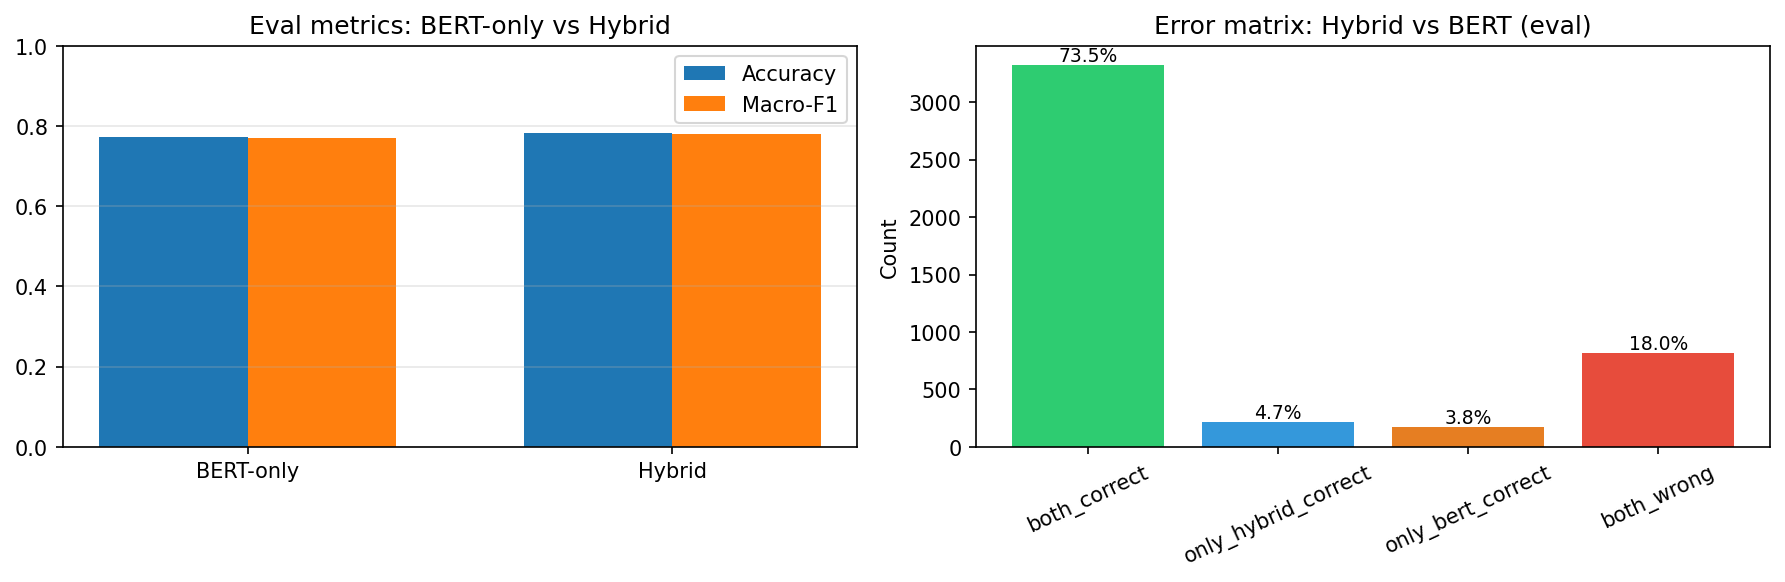

In [8]:
METRICS_PATH = Path(FINAL_METRICS_PATH)
ERROR_MATRIX_JSON = Path(ERROR_MATRIX_PATH)
FIG_PATH = Path(ERROR_MATRIX_FIG_PATH)

with open(METRICS_PATH, encoding='utf-8') as f:
    final_metrics = json.load(f)

with open(ERROR_MATRIX_JSON, encoding='utf-8') as f:
    err_matrix = json.load(f)

display(pd.Series({
    'bert_accuracy': final_metrics['bert_only']['accuracy'],
    'bert_macro_f1': final_metrics['bert_only']['macro_f1'],
    'hybrid_accuracy': final_metrics['hybrid']['accuracy'],
    'hybrid_macro_f1': final_metrics['hybrid']['macro_f1'],
    'threshold': final_metrics['threshold'],
    'low_conf_share': final_metrics['low_conf_share'],
    'total_time_min': final_metrics.get('total_time_min'),
}))

print('Error matrix counts:')
display(pd.Series(err_matrix['counts']))

if FIG_PATH.exists():
    display(Image(filename=str(FIG_PATH)))

## 6. Predictions preview

In [9]:
eval_preds = pd.read_parquet(Path(AGENT_EVAL_PREDS_PATH))
print('Routed to:')
print(eval_preds[COL_ROUTED_TO].value_counts())
print('Search used:', int(eval_preds[COL_SEARCH_USED].sum()), '/', len(eval_preds))
eval_preds.head()

Routed to:
routed_to
bert    3588
llm      970
Name: count, dtype: int64
Search used: 613 / 4558


,final_pred,routed_to,search_used,search_query,prompt_tokens,completion_tokens,permalink,label,latency_sec
0,0,llm,True,Оса Москва Новомосковский административный окр...,1152,60,106418039629,1,3.005
1,1,llm,False,None,860,8,1145303195,0,7.727
2,1,bert,False,None,0,0,1004138043,0,0.000
3,0,bert,False,None,0,0,47555692036,0,0.000
4,0,bert,False,None,0,0,158658797926,0,0.000


На прогон выше ушло 365 credits в Tavily